---
**ISBM COLLEGE OF ENGINEERING**  
**SUBJECT**: BDA LAB  
**STUDENT NAME**: RUSHIL CHAITANYA DHUBE  
**ROLL NUMBER**: 12  
**YEAR**: BE (2025-2026)  
**PRACTICAL**: 1

---

# Exploratory Data Analysis of the Iris Dataset

## Lab Objectives:
1. Load the Iris dataset into a DataFrame
2. Analyze features (count and data types)
3. Compute and display summary statistics
4. Create histograms for feature distributions
5. Create boxplots to identify outliers
6. Compare distributions and identify anomalies

In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

# Set style for visualizations
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [42]:
# Step 1: Download and Load the Iris Dataset
# Using sklearn's built-in iris dataset
from sklearn.datasets import load_iris

# Load the iris dataset
iris_data = load_iris()
iris_df = pd.DataFrame(data=iris_data.data, columns=iris_data.feature_names)
iris_df['species'] = iris_data.target_names[iris_data.target]

print("Dataset loaded successfully!")
print(f"\nDataset Shape: {iris_df.shape}")
print("\nFirst 5 rows of the dataset:")
print(iris_df.head())

Dataset loaded successfully!

Dataset Shape: (150, 5)

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [43]:
# Step 2: Feature Analysis
print("=" * 60)
print("FEATURE ANALYSIS")
print("=" * 60)

# Get dataset info
print("\nDataset Information:")
print(iris_df.info())

print("\n" + "=" * 60)
print("Feature Details:")
print("=" * 60)

# Display feature count and types
numeric_features = iris_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = iris_df.select_dtypes(include=['object']).columns.tolist()

print(f"\nTotal Features: {len(iris_df.columns)}")
print(f"Number of Numeric Features: {len(numeric_features)}")
print(f"Number of Categorical Features: {len(categorical_features)}")

print("\nNumeric Features:")
for i, feature in enumerate(numeric_features, 1):
    print(f"  {i}. {feature} - Type: Float64")

print("\nCategorical Features:")
for i, feature in enumerate(categorical_features, 1):
    print(f"  {i}. {feature} - Type: Nominal/String")
    print(f"     Unique values: {iris_df[feature].unique()}")

FEATURE ANALYSIS

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None

Feature Details:

Total Features: 5
Number of Numeric Features: 4
Number of Categorical Features: 1

Numeric Features:
  1. sepal length (cm) - Type: Float64
  2. sepal width (cm) - Type: Float64
  3. petal length (cm) - Type: Float64
  4. petal width (cm) - Type: Float64

Categorical Features:
  1. species - Type: Nominal/String
     Unique values: <StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str


C:\Users\rushi\AppData\Local\Temp\ipykernel_14332\3931321302.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = iris_df.select_dtypes(include=['object']).columns.tolist()


In [44]:
# Step 3: Compute and Display Summary Statistics
print("\n" + "=" * 60)
print("SUMMARY STATISTICS FOR NUMERIC FEATURES")
print("=" * 60)

# Get summary statistics using describe()
summary_stats = iris_df[numeric_features].describe()
print("\nBasic Statistics (count, mean, std, min, 25%, 50%, 75%, max):")
print(summary_stats.round(4))

# Compute additional statistics
print("\n" + "=" * 60)
print("EXTENDED STATISTICS")
print("=" * 60)

for feature in numeric_features:
    print(f"\n{feature.upper()}:")
    data = iris_df[feature]
    print(f"  Count:        {len(data)}")
    print(f"  Mean:         {data.mean():.4f}")
    print(f"  Median:       {data.median():.4f}")
    print(f"  Std Dev:      {data.std():.4f}")
    print(f"  Variance:     {data.var():.4f}")
    print(f"  Min:          {data.min():.4f}")
    print(f"  Max:          {data.max():.4f}")
    print(f"  Range:        {data.max() - data.min():.4f}")
    print(f"  25th Percentile: {data.quantile(0.25):.4f}")
    print(f"  50th Percentile: {data.quantile(0.50):.4f}")
    print(f"  75th Percentile: {data.quantile(0.75):.4f}")
    print(f"  IQR:          {data.quantile(0.75) - data.quantile(0.25):.4f}")
    print(f"  Skewness:     {stats.skew(data):.4f}")
    print(f"  Kurtosis:     {stats.kurtosis(data):.4f}")


SUMMARY STATISTICS FOR NUMERIC FEATURES

Basic Statistics (count, mean, std, min, 25%, 50%, 75%, max):
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count           150.0000          150.0000           150.0000   
mean              5.8433            3.0573             3.7580   
std               0.8281            0.4359             1.7653   
min               4.3000            2.0000             1.0000   
25%               5.1000            2.8000             1.6000   
50%               5.8000            3.0000             4.3500   
75%               6.4000            3.3000             5.1000   
max               7.9000            4.4000             6.9000   

       petal width (cm)  
count          150.0000  
mean             1.1993  
std              0.7622  
min              0.1000  
25%              0.3000  
50%              1.3000  
75%              1.8000  
max              2.5000  

EXTENDED STATISTICS

SEPAL LENGTH (CM):
  Count:        150
  Mean:        


GENERATING HISTOGRAMS FOR FEATURE DISTRIBUTIONS


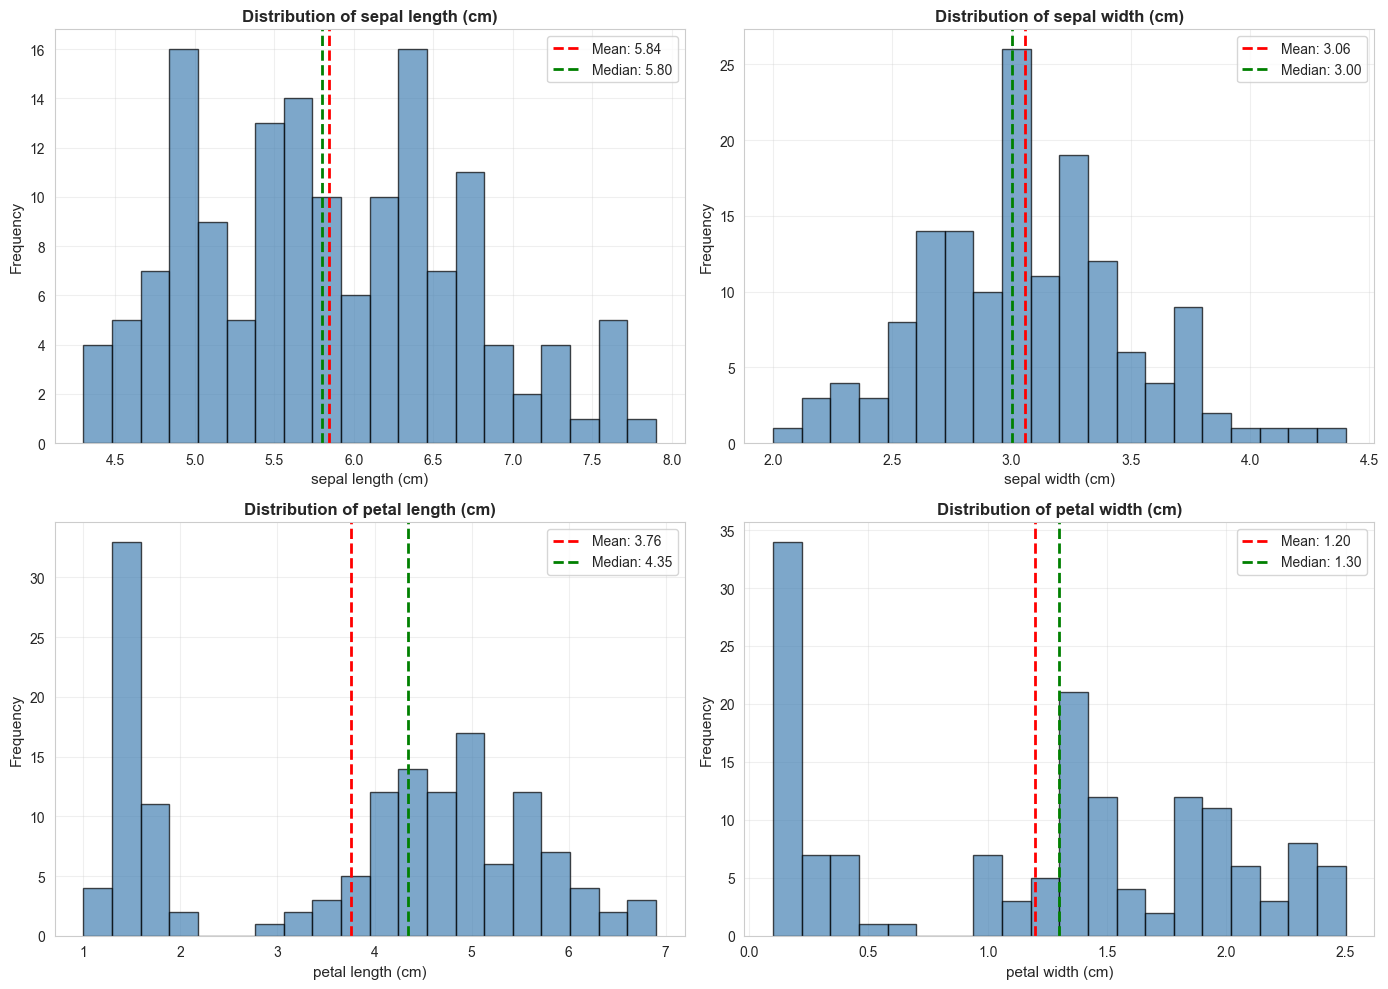


Histograms generated and saved as 'iris_histograms.png'


In [45]:
# Step 4: Data Visualization - Histograms
print("\n" + "=" * 60)
print("GENERATING HISTOGRAMS FOR FEATURE DISTRIBUTIONS")
print("=" * 60)

# Create histograms for each numeric feature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(numeric_features):
    axes[idx].hist(iris_df[feature], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].grid(True, alpha=0.3)
    
    # Add mean and median lines
    mean_val = iris_df[feature].mean()
    median_val = iris_df[feature].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('iris_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nHistograms generated and saved as 'iris_histograms.png'")


GENERATING BOXPLOTS FOR OUTLIER DETECTION


C:\Users\rushi\AppData\Local\Temp\ipykernel_14332\1121049942.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_boxplot, labels=numeric_features, patch_artist=True,


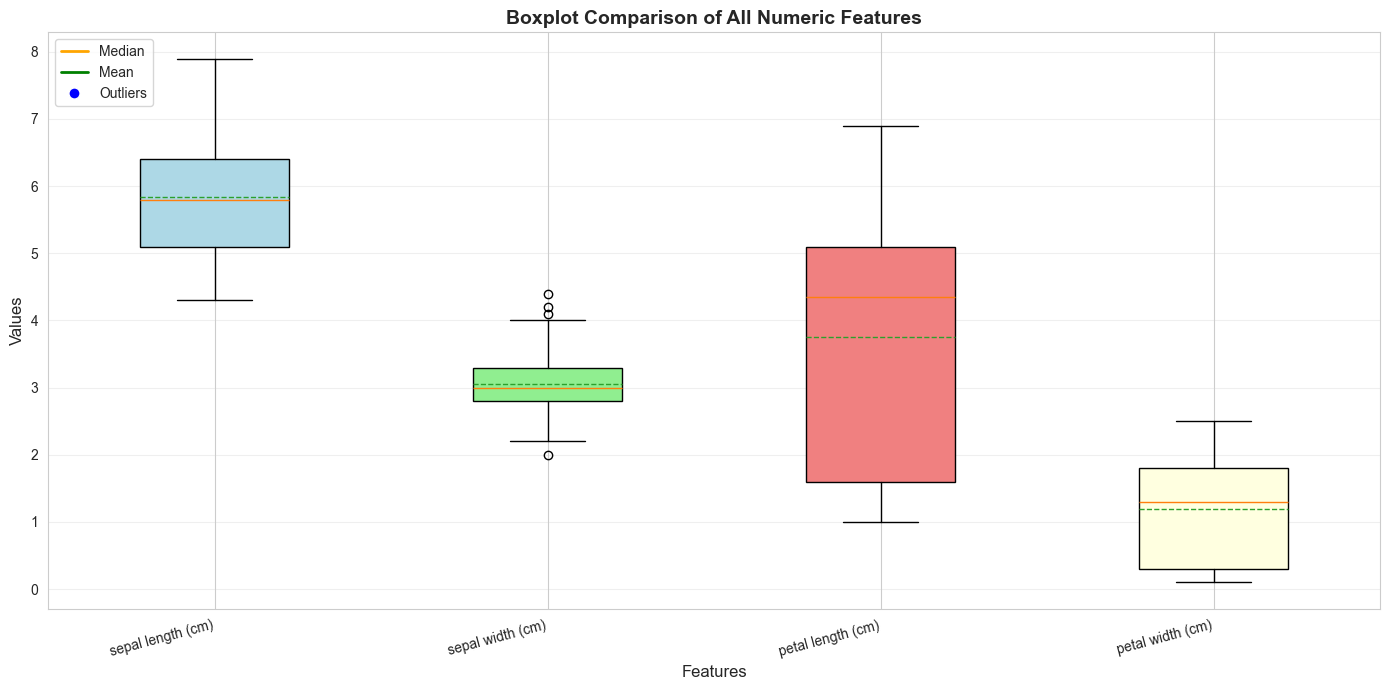


Combined boxplot generated and saved as 'iris_boxplots.png'


In [ ]:
# Step 5: Data Visualization - Boxplots
print("\n" + "=" * 60)
print("GENERATING BOXPLOTS FOR OUTLIER DETECTION")
print("=" * 60)

# Create combined boxplots for all numeric features
fig, ax = plt.subplots(figsize=(14, 7))

# Prepare data for boxplot
data_for_boxplot = [iris_df[feature] for feature in numeric_features]

# Create boxplot
bp = ax.boxplot(data_for_boxplot, labels=numeric_features, patch_artist=True,
                 notch=False, showmeans=True, meanline=True)

# Customize boxplot colors and styling
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_title('Boxplot Comparison of All Numeric Features', fontsize=14, fontweight='bold')
ax.set_ylabel('Values', fontsize=12)
ax.set_xlabel('Features', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Add legend
legend_elements = [
    plt.Line2D([0], [0], color='orange', linewidth=2, label='Median'),
    plt.Line2D([0], [0], color='green', linewidth=2, label='Mean'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Outliers')
]
ax.legend(handles=legend_elements, loc='upper left')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('iris_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCombined boxplot generated and saved as 'iris_boxplots.png'")

In [47]:
# Step 6: Outlier Detection and Analysis
print("\n" + "=" * 60)
print("OUTLIER DETECTION AND ANALYSIS")
print("=" * 60)

def identify_outliers_iqr(data):
    """Identify outliers using the IQR method"""
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data < lower_bound) | (data > upper_bound)

def identify_outliers_zscore(data, threshold=3):
    """Identify outliers using Z-score method"""
    z_scores = np.abs(stats.zscore(data))
    return z_scores > threshold

print("\nOutliers detected using IQR Method (1.5 × IQR):")
print("-" * 60)

for feature in numeric_features:
    outliers_mask = identify_outliers_iqr(iris_df[feature])
    outlier_count = outliers_mask.sum()
    print(f"\n{feature}:")
    print(f"  Total outliers: {outlier_count}")
    
    if outlier_count > 0:
        outlier_values = iris_df[outliers_mask][feature].values
        print(f"  Outlier values: {outlier_values}")
        outlier_indices = iris_df[outliers_mask].index.tolist()
        print(f"  Row indices: {outlier_indices}")
    else:
        print(f"  No outliers detected")

print("\n" + "-" * 60)
print("Outliers detected using Z-Score Method (|Z| > 3):")
print("-" * 60)

for feature in numeric_features:
    outliers_mask = identify_outliers_zscore(iris_df[feature], threshold=3)
    outlier_count = outliers_mask.sum()
    print(f"\n{feature}:")
    print(f"  Total outliers: {outlier_count}")
    
    if outlier_count > 0:
        outlier_values = iris_df[outliers_mask][feature].values
        print(f"  Outlier values: {outlier_values}")
        outlier_indices = iris_df[outliers_mask].index.tolist()
        print(f"  Row indices: {outlier_indices}")
    else:
        print(f"  No outliers detected")


OUTLIER DETECTION AND ANALYSIS

Outliers detected using IQR Method (1.5 × IQR):
------------------------------------------------------------

sepal length (cm):
  Total outliers: 0
  No outliers detected

sepal width (cm):
  Total outliers: 4
  Outlier values: [4.4 4.1 4.2 2. ]
  Row indices: [15, 32, 33, 60]

petal length (cm):
  Total outliers: 0
  No outliers detected

petal width (cm):
  Total outliers: 0
  No outliers detected

------------------------------------------------------------
Outliers detected using Z-Score Method (|Z| > 3):
------------------------------------------------------------

sepal length (cm):
  Total outliers: 0
  No outliers detected

sepal width (cm):
  Total outliers: 1
  Outlier values: [4.4]
  Row indices: [15]

petal length (cm):
  Total outliers: 0
  No outliers detected

petal width (cm):
  Total outliers: 0
  No outliers detected



DISTRIBUTION COMPARISON BY SPECIES


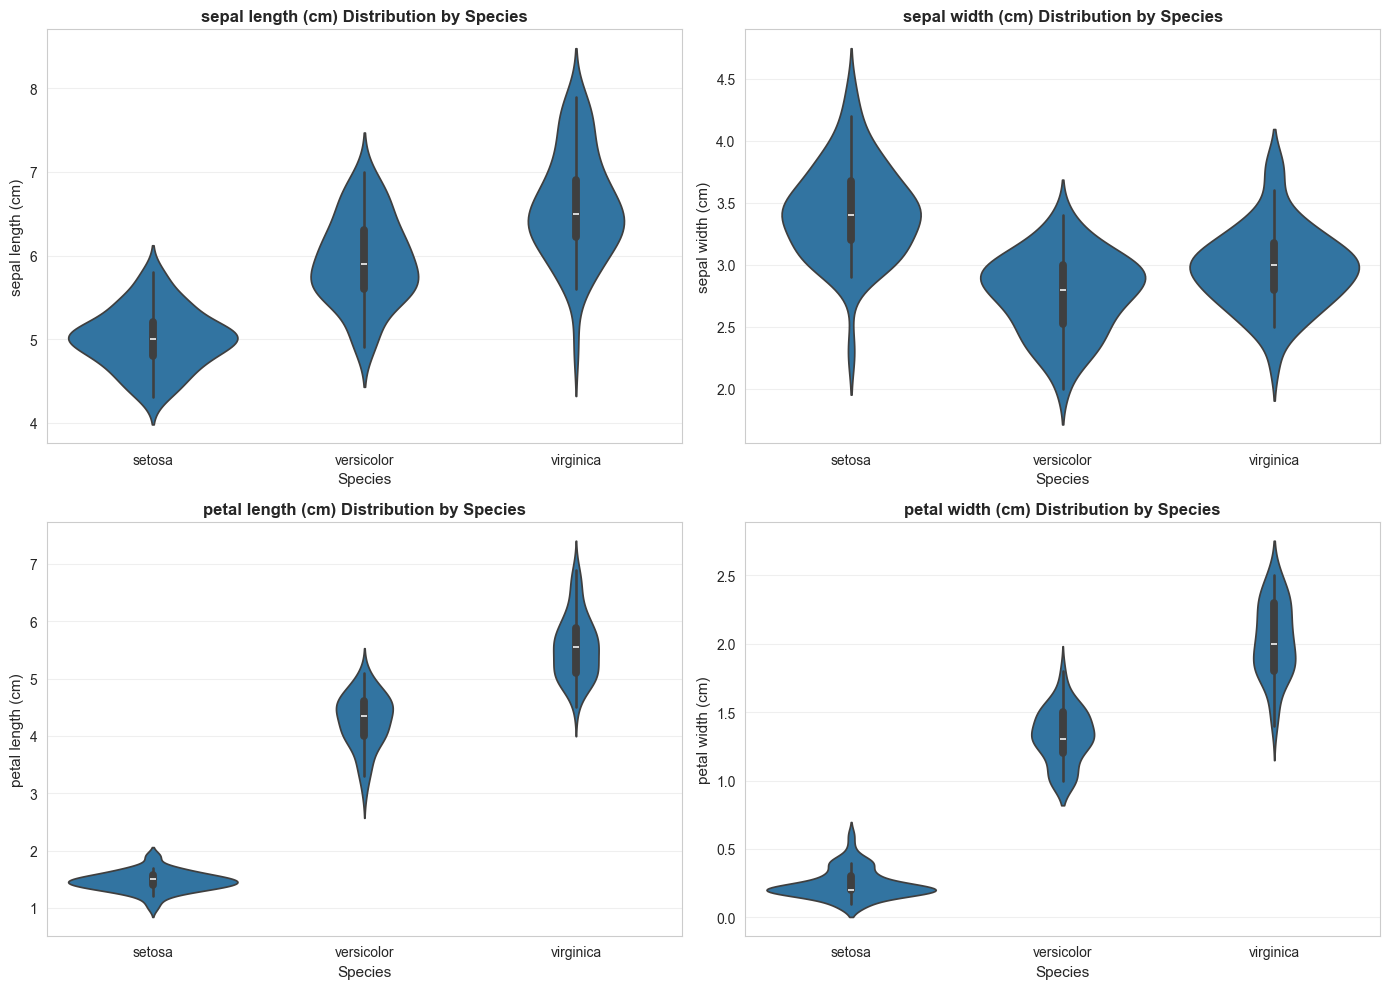


Violin plots generated and saved as 'iris_distributions_by_species.png'

------------------------------------------------------------
Summary Statistics by Species:
------------------------------------------------------------

SETOSA:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count            50.0000           50.0000            50.0000   
mean              5.0060            3.4280             1.4620   
std               0.3525            0.3791             0.1737   
min               4.3000            2.3000             1.0000   
25%               4.8000            3.2000             1.4000   
50%               5.0000            3.4000             1.5000   
75%               5.2000            3.6750             1.5750   
max               5.8000            4.4000             1.9000   

       petal width (cm)  
count           50.0000  
mean             0.2460  
std              0.1054  
min              0.1000  
25%              0.2000  
50%              0.200

In [48]:
# Step 7: Distribution Comparison by Species
print("\n" + "=" * 60)
print("DISTRIBUTION COMPARISON BY SPECIES")
print("=" * 60)

# Create violin plots to compare distributions across species
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(numeric_features):
    sns.violinplot(data=iris_df, x='species', y=feature, ax=axes[idx])
    axes[idx].set_title(f'{feature} Distribution by Species', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Species', fontsize=11)
    axes[idx].set_ylabel(feature, fontsize=11)
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('iris_distributions_by_species.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nViolin plots generated and saved as 'iris_distributions_by_species.png'")

# Summary statistics grouped by species
print("\n" + "-" * 60)
print("Summary Statistics by Species:")
print("-" * 60)

for species in iris_df['species'].unique():
    print(f"\n{species.upper()}:")
    species_data = iris_df[iris_df['species'] == species][numeric_features]
    print(species_data.describe().round(4))